<a href="https://colab.research.google.com/github/augustuswrobeh75-sys/Machine-Learning-with-Python-Boot_camp/blob/main/EDA_%26_Data_Cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Loading & preserving

In [3]:
import pandas as pd

# 1. The data link
url ="https://raw.githubusercontent.com/augustuswrobeh75-sys/Machine-Learning-with-Python-Boot_camp/refs/heads/main/market_dirty.csv"

# 2. read the data
df =pd.read_csv(url)

# 3. keep a raw copy for comparison
df_raw =df.copy()

#. Look as the first rows
print(df.head())


         date  rainfall_mm  transport_cost_lrd  supply_bags  price_lrd  \
0  2026-04-01         17.7              2935.0          158     3261.0   
1  2026-04-02         19.4              3843.0           45     4182.0   
2  2026-04-03         50.9              2655.0          218     2941.0   
3  2026-04-04          8.2              2268.0          221     4131.0   
4  2026-04-05         42.5              2369.0          220     3268.0   

   scarcity_alert  
0            True  
1            True  
2            True  
3           False  
4            True  


Asking Data Question

In [5]:
df.info()
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   date                40 non-null     object 
 1   rainfall_mm         40 non-null     float64
 2   transport_cost_lrd  40 non-null     float64
 3   supply_bags         40 non-null     int64  
 4   price_lrd           38 non-null     float64
 5   scarcity_alert      40 non-null     bool   
dtypes: bool(1), float64(3), int64(1), object(1)
memory usage: 1.7+ KB


,0
date,0
rainfall_mm,0
transport_cost_lrd,0
supply_bags,0
price_lrd,2
scarcity_alert,0


Removing Blank Prices

In [7]:
# Drop rows where price is empty
df = df.dropna(subset=['price_lrd'])

# See how many records survived
print(f'Orginal: {len(df_raw)}')
print(f'Clean:  {len(df)}')

Orginal: 40
Clean:  38


Filling in the Gps

In [9]:
#  1. Find the middle (median) transport cost
middle_cost = df['transport_cost_lrd']. median()

# 2. Fill in the blank cells with this middle value
df[ 'transport_cost_lrd'] = df['transport_cost_lrd'].fillna(middle_cost)

# varify: This blanks should now be 0
print(df['transport_cost_lrd'].isna().sum())

0


/tmp/ipykernel_1811/2485519706.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[ 'transport_cost_lrd'] = df['transport_cost_lrd'].fillna(middle_cost)


0.5 # The "Speed Limit"

In [14]:
# find the speed Limit (Top 5% boundary)
limit = df['price_lrd'].quantile(0.95)

#Bring the crazy spikes down to the limit
df['price_lrd']
df['price_lrd'].clip(upper=limit)

,price_lrd
0,3261.0
1,4182.0
2,2941.0
3,4131.0
4,3268.0
6,3848.0
7,3015.0
8,3539.0
9,3291.0
10,2835.0


Comparing Befor & After

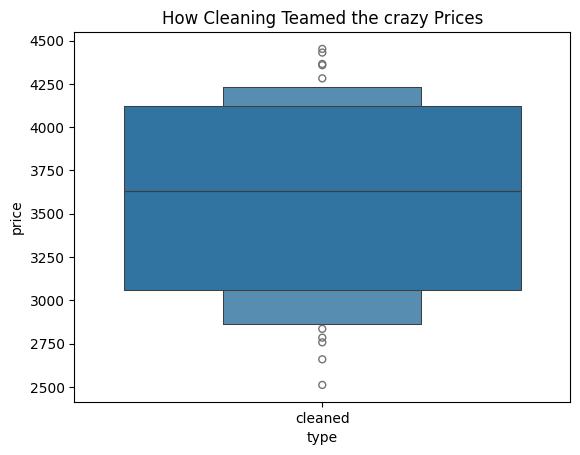

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# create a DataFrame for df_raw prices with a 'type' column
df_raw_plot = pd.DataFrame({ 'price': df_raw['price_lrd'],
                            'type': 'Raw (Messy)'
})


# create a Dateframe fo rdf (cleaned) prices with a 'type' column
df_cleaned_plot = pd.DataFrame({
    'price': df['price_lrd'], 'type': 'cleaned'
})

# Concatenate these two DataFrames, ignoring thier orginal indices, to create long-form data
plot_data = pd.concat([df_raw, df_cleaned_plot], ignore_index=True)

# Create a boxenplot
sns.boxenplot(x='type' , y='price', data=plot_data)
plt.title('How Cleaning Teamed the crazy Prices')
plt.show()


Regration

In [23]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np

# Load our model-Ready dataset
df = pd.read_csv('https://raw.githubusercontent.com/augustuswrobeh75-sys/Machine-Learning-with-Python-Boot_camp/refs/heads/main/gari_price_data.csv')
print(df.head())
print(df.shape)

   rainfall_mm  transport_cost_lrd  supply_bags  price_next_day_lrd
0         18.7                2702          111              3179.0
1         47.5                2401           86              3178.0
2         36.6                2729          148              3060.0
3         29.9                2161          153              2851.0
4          7.8                2201           84              2907.0
(50, 4)


Feature selection

In [25]:
# Verbatim Step 2 Code Block

x= df[['rainfall_mm' , 'transport_cost_lrd' , 'supply_bags']]
y= df['price_next_day_lrd']

x_train, x_test, y_train, y_test = train_test_split( x, y, test_size=0.2, random_state=42)

print('Training rows:' , x_train.shape[0])
print('Test rows:   ', x_test.shape[0])

Training rows: 40
Test rows:    10


In [26]:
# Verbatim Step 3 Code Block

model = LinearRegression()
model.fit(x_train, y_train)

print('Intercept: ' , round(model.intercept_, 2))
print('Coefficients: ' , dict(zip(x.columns, model. coef_.round(2))))

Intercept:  2464.17
Coefficients:  {'rainfall_mm': np.float64(4.3), 'transport_cost_lrd': np.float64(0.3), 'supply_bags': np.float64(-2.35)}
